In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
df = pd.read_csv('yearly.csv')

In [ ]:
df

,ano,janeiro,fevereiro,marco,abril,maio,junho,julho,agosto,setembro,outubro,novembro,dezembro
0,2019,75,957,835,672,405,42,18,33,21,18,25,258
1,2020,355,876,1058,872,210,61,61,61,31,54,30,88
2,2021,880,1270,1215,774,230,56,11,33,55,25,46,162
3,2022,805,1031,1183,549,141,47,14,27,21,29,25,102
4,2023,666,1119,1247,152,338,5,19,30,40,17,33,186
5,2024,650,1322,174,738,340,18,50,12,2,32,28,98
6,2025,469,718,709,413,40,68,10,23,30,30,16,53


In [ ]:
df['total'] = df.iloc[:, 1:].agg('sum', axis=1)
df

,ano,janeiro,fevereiro,marco,abril,maio,junho,julho,agosto,setembro,outubro,novembro,dezembro,total
0,2019,75,957,835,672,405,42,18,33,21,18,25,258,3359
1,2020,355,876,1058,872,210,61,61,61,31,54,30,88,3757
2,2021,880,1270,1215,774,230,56,11,33,55,25,46,162,4757
3,2022,805,1031,1183,549,141,47,14,27,21,29,25,102,3974
4,2023,666,1119,1247,152,338,5,19,30,40,17,33,186,3852
5,2024,650,1322,174,738,340,18,50,12,2,32,28,98,3464
6,2025,469,718,709,413,40,68,10,23,30,30,16,53,2579


In [ ]:
years = df['ano']
total = df['total']
months = df.loc[:,'janeiro':'dezembro']

<Axes: xlabel='ano', ylabel='total'>

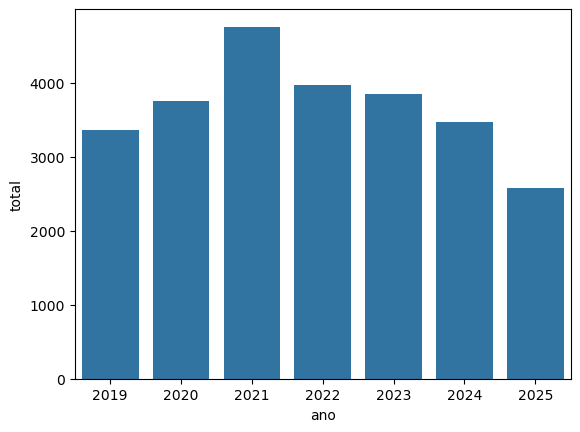

In [ ]:
sns.barplot(x = years, y = total)

<Axes: >

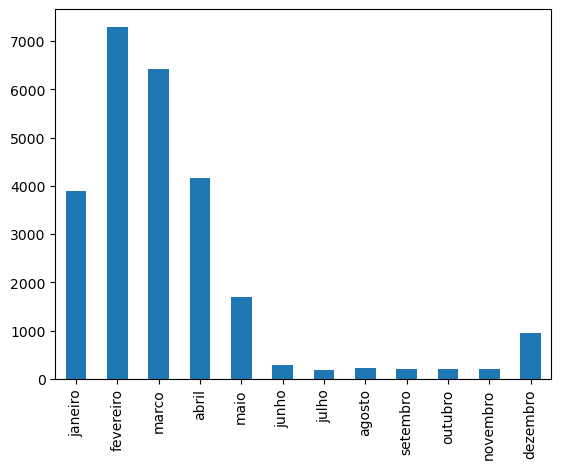

In [ ]:
months.sum().plot(kind='bar')

In [ ]:
df_long = df.melt(
    id_vars='ano',
    var_name='mes',
    value_name='analises'
)

X = pd.get_dummies(df_long[['mes', 'ano']], drop_first=True)
y = df_long['analises']

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# ===== 3. Coeficientes =====
coef = pd.Series(model.coef_, index=X.columns)

print("\n===== COEFICIENTES =====")
print(coef.sort_values())

print("\nIntercepto:", model.intercept_)

# ===== 4. Interpretação do ano =====
print("\n===== TENDÊNCIA ANUAL =====")
coef_ano = coef['ano']
print(f"A cada ano, as análises variam em: {coef_ano:.2f}")

# ===== 5. Interpretação dos meses =====
print("\n===== IMPACTO DOS MESES (comparado a janeiro) =====")

meses_coef = coef.drop('ano')

for mes, valor in meses_coef.items():
    print(f"{mes}: {valor:+.2f} análises em relação a janeiro")

# ===== 6. Melhor e pior mês =====
print("\n===== MELHOR E PIOR MÊS =====")

melhor_mes = meses_coef.idxmax()
pior_mes = meses_coef.idxmin()

print(f"Melhor mês: {melhor_mes} ({meses_coef.max():.2f})")
print(f"Pior mês: {pior_mes} ({meses_coef.min():.2f})")

# ===== 7. Avaliação do modelo =====
y_pred = model.predict(X)

print("\n===== QUALIDADE DO MODELO =====")
print("R²:", r2_score(y, y_pred))
print("MAE:", mean_absolute_error(y, y_pred))

# ===== 8. Exemplo de previsão =====
print("\n===== EXEMPLO DE PREVISÃO =====")

# exemplo: março de 2026
exemplo = pd.DataFrame({
    'ano': [2026],
    'mes': ['marco']
})

exemplo_X = pd.get_dummies(exemplo, drop_first=True)

# alinhar colunas com o modelo
exemplo_X = exemplo_X.reindex(columns=X.columns, fill_value=0)

previsao = model.predict(exemplo_X)

print(f"Previsão para março de 2026: {previsao[0]:.2f}")


===== COEFICIENTES =====
mes_julho        -569.571429
mes_setembro     -567.142857
mes_novembro     -566.714286
mes_outubro      -566.428571
mes_agosto       -564.428571
mes_junho        -553.285714
mes_dezembro     -460.428571
mes_maio         -352.285714
mes_janeiro       -38.571429
ano               -21.049451
mes_marco         321.571429
mes_fevereiro     446.142857
mes_total        3081.714286
dtype: float64

Intercepto: 43157.7032967033

===== TENDÊNCIA ANUAL =====
A cada ano, as análises variam em: -21.05

===== IMPACTO DOS MESES (comparado a janeiro) =====
mes_agosto: -564.43 análises em relação a janeiro
mes_dezembro: -460.43 análises em relação a janeiro
mes_fevereiro: +446.14 análises em relação a janeiro
mes_janeiro: -38.57 análises em relação a janeiro
mes_julho: -569.57 análises em relação a janeiro
mes_junho: -553.29 análises em relação a janeiro
mes_maio: -352.29 análises em relação a janeiro
mes_marco: +321.57 análises em relação a janeiro
mes_novembro: -566.71 anális

In [ ]:
# ===== 1. Criar dados de 2026 =====
meses = [
    'janeiro','fevereiro','marco','abril','maio','junho',
    'julho','agosto','setembro','outubro','novembro','dezembro'
]

df_2026 = pd.DataFrame({
    'ano': [2026]*12,
    'mes': meses
})

# ===== 2. Aplicar get_dummies =====
X_2026 = pd.get_dummies(df_2026, drop_first=True)

# ===== 3. Alinhar colunas com o modelo =====
X_2026 = X_2026.reindex(columns=X.columns, fill_value=0)

# ===== 4. Prever =====
df_2026['analises_previstas'] = model.predict(X_2026)

# ===== 5. Resultado =====
print(df_2026)

     ano        mes  analises_previstas
0   2026    janeiro          472.945055
1   2026  fevereiro          957.659341
2   2026      marco          833.087912
3   2026      abril          511.516484
4   2026       maio          159.230769
5   2026      junho          -41.769231
6   2026      julho          -58.054945
7   2026     agosto          -52.912088
8   2026   setembro          -55.626374
9   2026    outubro          -54.912088
10  2026   novembro          -55.197802
11  2026   dezembro           51.087912
